In [8]:
import pandas as pd

# Sadece başlıkları okumak için nrows=0 kullanıyoruz, anında çalışır.
cols_main = pd.read_csv("../data/raw/clinvar_missense.csv", nrows=0).columns.tolist()
cols_bio = pd.read_csv("../data/raw/clinvar_missense_bio.csv", nrows=0).columns.tolist()

print("Ana Tablo Sütunları:\n", cols_main)
print("\nBio Tablosu Sütunları:\n", cols_bio)

Ana Tablo Sütunları:
 ['VariationID', 'AlleleID', 'GeneSymbol', 'GeneID', 'HGNC_ID', 'Name', 'ClinicalSignificance', 'label_2class', 'ReviewStatus', 'NumberSubmitters', 'Guidelines', 'LastEvaluated', 'Origin', 'OriginSimple', 'PhenotypeList', 'PhenotypeIDS', 'RCVaccession', 'Assembly_variant_summary', 'ChromosomeAccession', 'Chromosome', 'Start', 'Stop', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'Cytogenetic', 'dbSNP_rs', 'VariantType', 'ClinSigSimple', 'TestedInGTR', 'OtherIDs', 'SubmitterCategories', 'SCVsForAggregateGermlineClassification', 'AlleleID_hgvs', 'Symbol_hgvs', 'GeneID_hgvs', 'HGVS_Type', 'Assembly_hgvs', 'NucleotideExpression', 'NucleotideChange', 'ProteinExpression', 'ProteinChange', 'ProteinChange_clean', 'aa_ref_3', 'aa_pos', 'aa_alt_3', 'UsedForNaming', 'Submitted', 'OnRefSeqGene', 'is_missense']

Bio Tablosu Sütunları:
 ['VariationID', 'AlleleID', 'GeneSymbol', 'GeneID', 'HGNC_ID', 'Name', 'ClinicalSignificance', 'label_2class', 'ReviewStatus', 'Num

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

print("Veriler yükleniyor...")
df_main = pd.read_csv("../data/raw/clinvar_missense.csv")
df_bio = pd.read_csv("../data/raw/clinvar_missense_bio.csv")

# 1. KOPYA SÜTUNLARI ENGELLEME
# 'VariationID' hariç, iki tabloda da olan ortak sütunları bulup Bio tablosundan atıyoruz
ortak_sutunlar = set(df_main.columns).intersection(set(df_bio.columns)) - {'VariationID'}
df_bio_temiz = df_bio.drop(columns=list(ortak_sutunlar))

# Şimdi güvenle Left Join yapabiliriz
df_merged = pd.merge(df_main, df_bio_temiz, on='VariationID', how='left')
print(f"Birleştirme başarılı! Satır: {df_merged.shape[0]}, Sütun: {df_merged.shape[1]}")

# 2. HEDEF VE ÖZELLİK (FEATURE) AYRIMI
# Hedef değişkenimiz büyük ihtimalle 'label_2class' (Pathogenic=1, Benign=0 gibi)
y = df_merged['label_2class']

# MODELİ EZBERE İTECEK SÜTUNLARI (LEAKAGE) VE GEREKSİZ ID'LERİ ÇÖPE ATIYORUZ
# ClinicalSignificance ve ClinSigSimple hedefin kopyasıdır, kesinlikle silinmeli!
silinecek_sutunlar = [
    'VariationID', 'AlleleID', 'GeneID', 'HGNC_ID', 'Name', 'RCVaccession', 
    'ChromosomeAccession', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 
    'dbSNP_rs', 'OtherIDs', 'AlleleID_hgvs', 'GeneID_hgvs', 'Assembly_hgvs', 
    'NucleotideExpression', 'NucleotideChange', 'ProteinExpression', 'ProteinChange', 
    'ProteinChange_clean', 'UsedForNaming', 'Submitted', 'NumberSubmitters',
    'ReviewStatus', 'Guidelines', 'LastEvaluated', 'PhenotypeList', 'PhenotypeIDS',
    'ClinicalSignificance', 'ClinSigSimple', 'label_2class' # Hedefleri X'ten çıkarıyoruz
]
X = df_merged.drop(columns=silinecek_sutunlar, errors='ignore')

# 3. KATEGORİK VE SAYISAL SÜTUNLARI TANIMLAMA
# Sadece modelin gerçekten kalıpları öğrenebileceği biyolojik ve istatistiksel verileri seçiyoruz
categorical_features = ['GeneSymbol', 'Chromosome', 'VariantType', 'OriginSimple', 'aa_ref_1', 'aa_alt_1']

numeric_features = [
    'grantham', 'blosum62', 'delta_hydrophobicity', 'delta_volume', 'delta_polarity', 
    'aai_GUYH850101_abs_delta', 'aai_FASG760101_abs_delta', 'aai_COHE430101_abs_delta', 
    'aai_ROSM880103_delta', 'aai_QIAN880122_delta', 'aai_BAEK050101_delta', 'aai_GEIM800105_delta'
]

# (Not: boolean olan 'is_transition', 'is_conservative_blosum', 'is_radical_grantham' 
# sütunlarını direkt numerik gibi muamele görebilirler veya kategorik de olabilir, 
# sayısal imputasyon onlara zarar vermez.)
numeric_features.extend(['is_transition', 'is_conservative_blosum', 'is_radical_grantham'])

# 4. VERİ SIZINTISINI ÖNLEYEN TRAIN/TEST AYRIMI (EN ÖNEMLİ ADIM)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. RANDOM FOREST İÇİN PIPELINE KURULUMU
# Sadece eksik verileri dolduruyoruz (Ağaç modelleri için Scale/Normalize etmiyoruz!)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Kategoriklerde çok fazla eşsiz değer (örn: gen isimleri) olabileceği için 
# One-Hot yerine OrdinalEncoder kullanmak Random Forest'ı inanılmaz hızlandırır ve rahatlatır.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Ön işlemeyi uyguluyoruz (fit_transform SADECE Train'e!)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Veri sızıntısı tamamen engellendi! Random Forest eğitimine hazır.")

Veriler yükleniyor...
Birleştirme başarılı! Satır: 4547, Sütun: 67
Veri sızıntısı tamamen engellendi! Random Forest eğitimine hazır.


Model eğitiliyor, ağaçlar büyüyor...

 SIZINTISIZ GERÇEK PERFORMANS SONUÇLARI 

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

      Benign       0.67      0.66      0.66       291
  Pathogenic       0.84      0.85      0.84       619

    accuracy                           0.79       910
   macro avg       0.75      0.75      0.75       910
weighted avg       0.78      0.79      0.79       910



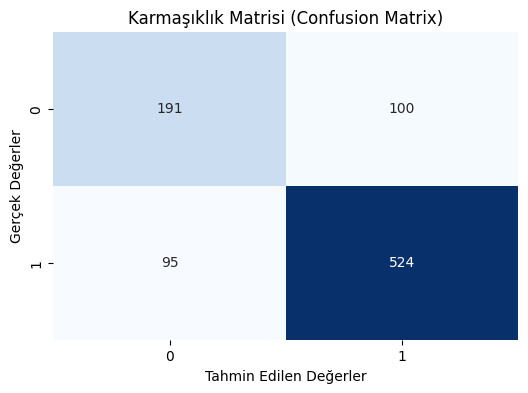

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. MODELİ TANIMLAMA
# class_weight='balanced': Azınlık sınıfına daha fazla önem vererek sınıf dengesizliğini çözer
# n_jobs=-1: Bilgisayardaki tüm çekirdekleri kullanarak eğitimi hızlandırır
rf_model = RandomForestClassifier(n_estimators=100, 
                                  random_state=42, 
                                  class_weight='balanced', 
                                  n_jobs=-1)

# 2. EĞİTİMİ BAŞLATMA
print("Model eğitiliyor, ağaçlar büyüyor...")
rf_model.fit(X_train_processed, y_train)

# 3. TEST SETİ ÜZERİNDE TAHMİN (Gerçek Sınav)
y_pred = rf_model.predict(X_test_processed)

# 4. PERFORMANS DEĞERLENDİRMESİ
print("\n" + "="*40)
print(" SIZINTISIZ GERÇEK PERFORMANS SONUÇLARI ")
print("="*40)

print("\n--- Sınıflandırma Raporu ---")
# Hedef değişkenindeki 0 ve 1'in neye denk geldiğini biliyorsan target_names=['Benign', 'Pathogenic'] eklenebilir
print(classification_report(y_test, y_pred))

# 5. KARMAŞIKLIK MATRİSİNİ GÖRSELLEŞTİRME
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

In [12]:
# BU KODU ESKİ (Random Forest) NOTEBOOK'UNDA ÇALIŞTIR
import os

# processed klasörünün var olduğundan emin olalım
os.makedirs("../data/processed", exist_ok=True)

# Verileri diske kaydediyoruz
X_train.to_csv("../data/processed/X_train_text.csv", index=False)
X_test.to_csv("../data/processed/X_test_text.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Veriler başarıyla data/processed altına kaydedildi!")

Veriler başarıyla data/processed altına kaydedildi!


In [14]:
import pandas as pd
import numpy as np

# İşlenmiş sayısal verileri (numpy array'dir bunlar) CSV olarak kaydediyoruz
pd.DataFrame(X_train_processed).to_csv("../data/processed/X_train_numeric.csv", index=False)
pd.DataFrame(X_test_processed).to_csv("../data/processed/X_test_numeric.csv", index=False)

print("Sayısal özellikler başarıyla dışa aktarıldı!")

Sayısal özellikler başarıyla dışa aktarıldı!
